
# ShiftGuard10 v7 — 3-Seed Ensemble | 300 Epochs · WRN-40-10 · Distribution-Shift Robust | Target F1 > 0.95
# WideResNet-40-10 · BalancedSoftmaxLoss · SWA(ep225+) · AugMix · GreyCutout · RandomErasing · GaussianNoise · Seeds[23,71,314] · 30-round TTA

# 🏗️ Architecture — WideResNet-28-10
# The backbone is a Wide Residual Network (WRN-28-10), a well-established architecture for small-image classification. It has:

# Depth 40, Width factor 10 → channel progression: 16 → 160 → 320 → 640
# 3 stages of residual blocks, each with stride-2 downsampling between stages
# Pre-activation residual blocks (BN → ReLU → Conv) with a 1×1 projection shortcut when dimensions change
# Dropout (p=0.3) inside every residual block for regularization
# Global average pooling followed by a single linear classifier head
# Weights initialized via Kaiming Normal (conv), Xavier Normal (linear), ones/zeros (BN)
# Compiled with torch.compile() where available for faster training

# Total parameters: ~54M  (depth 34→40: +1 block per stage, 5→6)

# 📊 Dataset & Split

# 10-class RGB image classification on 32×32 images: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
# 95/5 stratified train/val split (maximizes training data while keeping a calibration set)
# Competition note: test set contains distribution shift relative to training — robustness techniques are essential


# ⚖️ Class Imbalance Handling
# Two complementary strategies:
# 1. WeightedRandomSampler — oversamples minority classes during training using sqrt-inverse frequency weighting (softer than pure inverse, avoids extreme oversampling of very rare classes)
# 2. BalancedSoftmaxLoss — adds log(class_frequency) as a bias to logits before cross-entropy. This shifts decision boundaries toward rarer classes at the loss level, complementing the sampler. Combined with label smoothing (ε=0.1) to prevent overconfident predictions.

# 🔁 Training Pipeline
# Optimizer & Schedule

# SGD with momentum=0.9, weight_decay=5e-4, Nesterov=True, initial lr=0.1
# 5-epoch linear warmup followed by cosine annealing to 0 over remaining epochs
# Mixed precision (AMP) via GradScaler on CUDA for speed
# Gradient clipping at norm=1.0 to prevent exploding gradients

# Stochastic Weight Averaging (SWA)

# Activates at epoch 225 (75% through training), runs for the final 75 epochs
# Uses SWALR with swa_lr=0.01, anneal_epochs=10
# After training, BatchNorm statistics are recalculated on the training set for the SWA model
# SWA model is saved as best only if it beats the best per-epoch checkpoint on val F1

# Batch-level Augmentation (CutMix + MixUp)
# Each training batch has a 50% chance of applying one of:

# CutMix (25%) — pastes a rectangular region from a shuffled image, labels mixed proportionally by area
# MixUp (25%) — linear interpolation of two images and their labels (α=0.4)
# Standard CE (50%) — normal batch with BalancedSoftmaxLoss

# Both soft-label variants use the same log_freq bias from BalancedSoftmaxLoss via a custom soft_ce() function.

# 🖼️ Image Augmentation Pipeline
# Training transforms (applied per image):
# StepDetailsRandomCrop 32×32padding=4, reflect modeRandomHorizontalFlipp=0.5ColorJitterbrightness=0.1, contrast=0.1, saturation=0.1, hue=0.02AugMix(severity=2)Distribution-shift robust mixing augmentationToTensor + NormalizeCIFAR10 mean/std: μ=[0.491,0.482,0.447], σ=[0.247,0.244,0.262]GreyCutout (5–12px)p=0.5, fills with normalized grey (~0.5 in pixel space)
# Why GreyCutout instead of standard black Cutout:
# The dataset contains real grey square artifacts (5–10px) in some train and test images. Standard Cutout fills with black (0 after normalization = dataset mean), which does not match these artifacts. GreyCutout fills with the correctly normalized grey value (0.5 - μ) / σ per channel, teaching the model to handle these exact test-time corruptions. Size range 5–12px slightly exceeds the observed 5–10px to add margin.

# 🔮 Inference — 3-Seed Ensemble + 30-round TTA
# Each of the 3 trained models contributes via Test-Time Augmentation (TTA):

# 30 stochastic passes using the full TTA transform (RandomCrop + Flip + ColorJitter + AugMix + GaussianNoise)
# 1 clean pass (no augmentation) weighted 3× to anchor predictions
# Final per-model probabilities: (sum_of_30_tta + 3 × clean) / 33
# 3 model outputs are averaged (equal weight) to form the final ensemble prediction
# Submission generated after each seed completes so a valid CSV always exists


# 🌱 Reproducibility
# Three independent seeds [23, 71, 314] are used. Each seed re-initializes the model, optimizer, sampler, and all random states via seed_everything(). The ensemble diversity comes from different random augmentation sequences, weight initializations, and sampling orders — not from architecture changes.

# 📋 Key Hyperparameters
# ParameterValueEpochs200SWA startEpoch 150Batch size256Initial LR0.1 (cosine → 0)SWA LR0.01Weight decay5e-4Dropout0.3Label smoothing0.1Train/Val split95% / 5%TTA rounds30 + 1 clean (×3)Seeds23, 71, 314

In [1]:
# ── 1. Imports & Device ───────────────────────────────────────────────────────
import os, math, random, time, warnings, datetime
import numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

def seed_everything(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_OK = DEVICE.type == "cuda"
print(f"Device : {DEVICE}")
if AMP_OK:
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"AMP    : {AMP_OK}")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
AMP    : True


In [2]:
# ── 2. Paths & Classes ────────────────────────────────────────────────────────
def find_root():
    for c in [
        Path("/kaggle/input/datasets/kausheyk01/s22lk"),
        Path("/kaggle/input/datasets/kausheyk01/s-22lk"),
        Path("/kaggle/input/datasets/singhaarush2005/ee708-data"),
        Path("/kaggle/input/s22lk"),
    ]:
        if c.exists() and (c/"train_labels.csv").exists(): return c
    for p in Path("/kaggle/input").rglob("train_labels.csv"):
        return p.parent
    raise FileNotFoundError("Dataset not found")

ROOT       = find_root()
TRAIN_IMGS = ROOT / "train_images"
TEST_IMGS  = ROOT / "test_images"
LABELS_CSV = ROOT / "train_labels.csv"
SAMPLE_SUB = ROOT / "sample_submission.csv"
WORK_DIR   = Path("/kaggle/working")
SUB_PATH   = WORK_DIR / "submission.csv"
print("Dataset:", ROOT)

# Load classes
CLASSES_TXT = ROOT / "classes.txt"
if CLASSES_TXT.exists():
    classes = [l.strip() for l in open(CLASSES_TXT) if l.strip()]
else:
    classes = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

NUM_CLASSES = len(classes)
cls2idx     = {c: i for i, c in enumerate(classes)}
idx2cls     = {i: c for c, i in cls2idx.items()}
print(f"Classes ({NUM_CLASSES}): {classes}")

raw    = pd.read_csv(LABELS_CSV, dtype={pd.read_csv(LABELS_CSV).columns[0]: str})
ID_COL = raw.columns[0]; LBL_COL = raw.columns[1]
raw["label_idx"] = raw[LBL_COL].map(cls2idx) if raw[LBL_COL].dtype==object else raw[LBL_COL]
print(f"Total: {len(raw)} samples")
print(raw["label_idx"].value_counts().sort_index())


Dataset: /kaggle/input/datasets/singhaarush2005/ee708-data
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total: 29400 samples
label_idx
0    5000
1    5000
2    5000
3    5000
4    4000
5    4000
6     500
7     500
8     300
9     100
Name: count, dtype: int64


In [3]:
# ── 3. Split — 95/5  ─────────────────────────
train_df, val_df = train_test_split(
    raw, test_size=0.05,  
    stratify=raw["label_idx"], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)}  Val: {len(val_df)}")

# Class frequencies for BalancedSoftmaxLoss and sampler
cls_counts = train_df["label_idx"].value_counts().sort_index().values.astype(float)
print("Class counts:", cls_counts.astype(int))


Train: 27930  Val: 1470
Class counts: [4750 4750 4750 4750 3800 3800  475  475  285   95]


In [4]:
# ── 4. Dataset ────────────────────────────────────────────────────────────────
class ImgDS(Dataset):
    def __init__(self, frame, img_dir, tfm, id_col, lbl_col=None, is_test=False):
        self.frame   = frame.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfm     = tfm
        self.id_col  = id_col
        self.lbl_col = lbl_col
        self.is_test = is_test

    def __len__(self): return len(self.frame)

    def _find(self, stem):
        stem = str(stem).zfill(6)
        for ext in (".png", ".jpg", ".jpeg", ""):
            p = self.img_dir / f"{stem}{ext}"
            if p.exists(): return p
        raise FileNotFoundError(f"Not found: {stem}")

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(self._find(row[self.id_col])).convert("RGB")
        img = self.tfm(img)
        if self.is_test: return img, str(row[self.id_col])
        return img, int(row[self.lbl_col])


In [5]:
# ── 5. Augmentation — AugMix + GreyCutout + RandomErasing + GaussianNoise ────
MU  = [0.4914, 0.4822, 0.4465]
SIG = [0.2470, 0.2435, 0.2616]

# Normalized fill value for a 128/255 grey pixel — matches dataset cutout color
GREY_FILL = [(0.5 - m) / s for m, s in zip(MU, SIG)]  # ≈ [0.035, 0.073, 0.205]

class GreyCutout:
    """
    Simulates the grey cutout artifacts (5–10px) present in the dataset.
    Fills a random square patch with normalized grey instead of black (0),
    so the model learns to handle these exact artifacts at inference time.
    p=0.5 applies it to ~half of training images.
    """
    def __init__(self, min_size=5, max_size=12, p=0.5):
        self.min_size = min_size
        self.max_size = max_size
        self.p        = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        _, H, W = img.shape
        size = random.randint(self.min_size, self.max_size)
        y    = random.randint(0, H - 1)
        x    = random.randint(0, W - 1)
        y1, y2 = max(y - size // 2, 0), min(y + size // 2, H)
        x1, x2 = max(x - size // 2, 0), min(x + size // 2, W)
        for c, fill_val in enumerate(GREY_FILL):
            img[c, y1:y2, x1:x2] = fill_val
        return img


class GaussianNoise:
    """
    Adds small zero-mean Gaussian noise to a normalized tensor.
    Trains the model to be robust to subtle pixel-level perturbations —
    exactly the kind of distribution shift described in this competition.
    sigma=0.03 corresponds to ~7/255 in pixel space — visually imperceptible.
    """
    def __init__(self, sigma=0.03, p=0.5):
        self.sigma = sigma
        self.p     = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        return img + torch.randn_like(img) * self.sigma


# ── Training transforms ───────────────────────────────────────────────────────
# AugMix replaces AutoAugment: AugMix was explicitly designed for distribution-
# shift robustness (Jensen-Shannon consistency). AutoAugment optimises clean
# accuracy only. severity=2 keeps augmentations mild so clean performance is
# preserved while generalisation to shifted test images improves.
train_tfm = T.Compose([
    T.RandomCrop(32, padding=4, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.AugMix(severity=2, mixture_width=3),        # ← replaces AutoAugment
    T.ToTensor(),
    T.Normalize(MU, SIG),
    GreyCutout(min_size=5, max_size=12, p=0.5),   # matches dataset grey artifacts
    # RandomErasing with random-noise fill — covers occlusion patterns different
    # from GreyCutout's specific grey value; scale=2–10% keeps patches small
    T.RandomErasing(p=0.3, scale=(0.02, 0.10), ratio=(0.5, 2.0), value="random"),
    GaussianNoise(sigma=0.03, p=0.5),             # subtle perturbation robustness
])

# ── Validation transform — clean, no augmentation ────────────────────────────
val_tfm = T.Compose([T.ToTensor(), T.Normalize(MU, SIG)])

# ── TTA transform — stochastic, corruption-aware ─────────────────────────────
# AugMix in TTA diversifies the 30 passes across the augmentation manifold
# that AugMix defines, which is closely aligned with the distribution-shift
# test set. GaussianNoise at sigma=0.02 means some TTA passes will have
# slight noise, matching perturbed test images more closely.
tta_tfm = T.Compose([
    T.RandomCrop(32, padding=4, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.01),
    T.AugMix(severity=2, mixture_width=3),        # ← replaces AutoAugment
    T.ToTensor(),
    T.Normalize(MU, SIG),
    GaussianNoise(sigma=0.02, p=0.3),             # mild — covers perturbed test images
])

print("Transforms ready: AugMix + GreyCutout + RandomErasing + GaussianNoise")
print(f"  GREY_FILL (normalized): {[round(v,3) for v in GREY_FILL]}")
print("  AugMix severity=2  (distribution-shift robust, preserves clean accuracy)")
print("  RandomErasing p=0.3, scale 2–10%, random-noise fill (occlusion variety)")
print("  GaussianNoise sigma=0.03 train / 0.02 TTA  (~7px / ~5px noise in [0,255])")


Transforms ready: AutoAugment + ColorJitter + GreyCutout(5–12px grey)
  GREY_FILL (normalized): [0.035, 0.073, 0.205]


In [6]:
# ── 6. DataLoader Builder ─────────────────────────────────────────────────────
BATCH     = 256
N_WORKERS = 4

def make_loaders(train_df, val_df, cls_counts):
    # Sqrt-inverse frequency weighting — softer than pure inverse
    sw      = (1.0 / np.sqrt(cls_counts))[train_df["label_idx"].values]
    sampler = WeightedRandomSampler(sw, num_samples=len(train_df), replacement=True)

    tr_ds = ImgDS(train_df, TRAIN_IMGS, train_tfm, ID_COL, "label_idx")
    va_ds = ImgDS(val_df,   TRAIN_IMGS, val_tfm,   ID_COL, "label_idx")

    tr_dl = DataLoader(tr_ds, batch_size=BATCH, sampler=sampler,
                       num_workers=N_WORKERS, pin_memory=True,
                       drop_last=True, persistent_workers=True)
    va_dl = DataLoader(va_ds, batch_size=BATCH, shuffle=False,
                       num_workers=N_WORKERS, pin_memory=True,
                       persistent_workers=True)
    return tr_dl, va_dl

train_loader, val_loader = make_loaders(train_df, val_df, cls_counts)
print(f"Batch={BATCH}  train={len(train_loader)} batches  val={len(val_loader)} batches")
print("Sampler: sqrt-inverse frequency weighting")


Batch=256  train=109 batches  val=6 batches
Sampler: sqrt-inverse frequency weighting


In [7]:
# ── 7. WideResNet-28-10 (channels 16→160→320→640) ────────────────────────────
class WideBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride, drop=0.3):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.drop  = nn.Dropout(drop)
        self.proj  = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                      if stride != 1 or in_ch != out_ch else nn.Identity())

    def forward(self, x):
        h = self.conv1(F.relu(self.bn1(x), inplace=True))
        h = self.drop(h)
        h = self.conv2(F.relu(self.bn2(h), inplace=True))
        return h + self.proj(x)


class WideResNet(nn.Module):
    """WRN-40-10: channels 16→160→320→640 — depth 40, 6 blocks per stage"""
    def __init__(self, depth=40, width=10, nc=10, drop=0.3):
        super().__init__()
        assert (depth-4) % 6 == 0
        n  = (depth-4) // 6
        ch = [16, 16*width, 32*width, 64*width]  # 16,160,320,640
        self.stem   = nn.Conv2d(3, ch[0], 3, padding=1, bias=False)
        self.stage1 = self._make(ch[0], ch[1], n, 1, drop)
        self.stage2 = self._make(ch[1], ch[2], n, 2, drop)
        self.stage3 = self._make(ch[2], ch[3], n, 2, drop)
        self.bn_out = nn.BatchNorm2d(ch[3])
        self.head   = nn.Linear(ch[3], nc)
        self._init()

    def _make(self, ic, oc, n, s, d):
        return nn.Sequential(WideBlock(ic, oc, s, d),
                             *[WideBlock(oc, oc, 1, d) for _ in range(n-1)])

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x)
        x = F.adaptive_avg_pool2d(F.relu(self.bn_out(x), inplace=True), 1)
        return self.head(x.flatten(1))

print("WideResNet-40-10 defined (16→160→320→640) — 6 blocks/stage")


WideResNet-28-10 defined (16→160→320→640)


In [8]:
# ── 8. BalancedSoftmaxLoss───────────────────────
# Adds log(class_frequency) to logits before CE
# Biases model toward predicting rare classes more — better for imbalance

class BalancedSoftmaxLoss(nn.Module):
    def __init__(self, cls_counts, label_smoothing=0.1):
        super().__init__()
        freq   = torch.tensor(cls_counts, dtype=torch.float)
        freq   = freq / freq.sum()
        # log(freq) added to logits — shifts decision boundary for rare classes
        self.register_buffer("log_freq", torch.log(freq))
        self.smoothing = label_smoothing

    def forward(self, logits, targets):
        # Add log-frequency bias to logits
        adj_logits = logits + self.log_freq.to(logits.device)
        return F.cross_entropy(adj_logits, targets,
                               label_smoothing=self.smoothing)

bsl = BalancedSoftmaxLoss(cls_counts, label_smoothing=0.1)
print("BalancedSoftmaxLoss ready")
print(f"  log_freq bias: {bsl.log_freq.numpy().round(3)}")


BalancedSoftmaxLoss ready
  log_freq bias: [-1.772 -1.772 -1.772 -1.772 -1.995 -1.995 -4.074 -4.074 -4.585 -5.684]


In [9]:
# ── 9. CutMix + MixUp (CPU-safe, 50% chance per batch ────────────
def rand_bbox(hw, lam):
    H, W   = hw
    r      = math.sqrt(1 - lam)
    cw, ch = int(W*r), int(H*r)
    cx, cy = random.randint(0, W), random.randint(0, H)
    return max(cx-cw//2,0), max(cy-ch//2,0), min(cx+cw//2,W), min(cy+ch//2,H)

def do_cutmix(imgs, lbls, nc, alpha=1.0):
    lam          = np.random.beta(alpha, alpha)
    idx          = torch.randperm(imgs.size(0))
    x1,y1,x2,y2 = rand_bbox(imgs.shape[2:], lam)
    out = imgs.clone()
    out[:,:,y1:y2,x1:x2] = imgs[idx,:,y1:y2,x1:x2]
    adj  = 1-(x2-x1)*(y2-y1)/(imgs.shape[-1]*imgs.shape[-2])
    soft = adj*F.one_hot(lbls.cpu(),nc).float()+(1-adj)*F.one_hot(lbls[idx].cpu(),nc).float()
    return out, soft

def do_mixup(imgs, lbls, nc, alpha=0.4):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(imgs.size(0))
    mix  = lam*imgs + (1-lam)*imgs[idx]
    soft = lam*F.one_hot(lbls.cpu(),nc).float()+(1-lam)*F.one_hot(lbls[idx].cpu(),nc).float()
    return mix, soft

def soft_ce(logits, soft, log_freq):
    """Soft cross-entropy with BalancedSoftmax bias."""
    adj = logits + log_freq.to(logits.device)
    return -(soft * F.log_softmax(adj, 1)).sum(1).mean()

print("CutMix / MixUp ready (50% chance per batch)")


CutMix / MixUp ready (50% chance per batch)


In [10]:
# ── 10. Single-Seed Training Function ─────────────────────────────────────────
def train_one_seed(seed, epochs=300, swa_start=225):
    """
    Train one WRN-40-10 with full pipeline for one seed.
    Saves checkpoint every epoch — resumes automatically if interrupted.
    SWA starts at swa_start epoch.
    """
    seed_everything(seed)
    ckpt_path = WORK_DIR / f"ckpt_seed{seed}.pth"
    best_path = WORK_DIR / f"best_seed{seed}.pth"

    # Build fresh model + optimizer + SWA
    net = WideResNet(depth=40, width=10, nc=NUM_CLASSES, drop=0.3).to(DEVICE)
    try:
        net = torch.compile(net)
    except Exception:
        pass

    swa_model = AveragedModel(net)
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9,
                          weight_decay=5e-4, nesterov=True)

    # Cosine annealing to 0 ("cosine annealing to 0")
    def lr_fn(ep):
        warmup = 5
        if ep < warmup: return (ep+1)/warmup
        t = (ep-warmup) / max(epochs-warmup, 1)
        return max(0.5*(1+math.cos(math.pi*t)), 0.0)

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
    swa_sched = SWALR(optimizer, swa_lr=0.01, anneal_epochs=10)
    scaler    = GradScaler(enabled=AMP_OK)
    bsl_dev   = BalancedSoftmaxLoss(cls_counts, label_smoothing=0.1).to(DEVICE)
    log_freq  = bsl_dev.log_freq

    best_f1   = 0.0
    start_ep  = 1
    ep_times  = []

    # ── Resume logic — restarts from last saved epoch ─────────────────────────
    if ckpt_path.exists():
        print(f"  Resuming seed={seed} from {ckpt_path}...")
        ck = torch.load(ckpt_path, map_location=DEVICE)
        net.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optim"])
        scheduler.load_state_dict(ck["sched"])
        scaler.load_state_dict(ck["scaler"])
        best_f1  = ck["best_f1"]
        start_ep = ck["epoch"] + 1
        if "swa_model" in ck and ck["epoch"] >= swa_start:
            swa_model.load_state_dict(ck["swa_model"])
        print(f"  Resumed at epoch {start_ep}  best_f1={best_f1:.4f}")

    print(f"{'='*70}")
    print(f"Seed={seed}  Epochs={epochs}  SWA starts ep{swa_start}")
    print(f"{'Ep':>4}  {'Loss':>8}  {'F1':>7}  {'Best':>7}  {'EpTime':>7}  {'ETA':>8}  Note")
    print(f"{'-'*70}")

    t_start = time.time()

    for ep in range(start_ep, epochs+1):
        t0 = time.time()
        net.train()
        total_loss = total_n = 0

        for imgs, lbls in train_loader:
            # 50% chance MixUp or CutMix , alternating
            dice = random.random()
            if dice < 0.25:
                imgs, soft = do_cutmix(imgs, lbls, NUM_CLASSES)
                imgs = imgs.to(DEVICE, non_blocking=True)
                soft = soft.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=AMP_OK):
                    loss = soft_ce(net(imgs), soft, log_freq)
            elif dice < 0.50:
                imgs, soft = do_mixup(imgs, lbls, NUM_CLASSES)
                imgs = imgs.to(DEVICE, non_blocking=True)
                soft = soft.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=AMP_OK):
                    loss = soft_ce(net(imgs), soft, log_freq)
            else:
                imgs = imgs.to(DEVICE, non_blocking=True)
                lbls = lbls.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=AMP_OK):
                    loss = bsl_dev(net(imgs), lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()

            total_loss += loss.item()*imgs.size(0)
            total_n    += imgs.size(0)

        tr_loss = total_loss / total_n

        # SWA update
        if ep >= swa_start:
            swa_model.update_parameters(net)
            swa_sched.step()
        else:
            scheduler.step()

        # Validate
        net.eval()
        ps, ls = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                with autocast(enabled=AMP_OK):
                    ps.extend(net(imgs.to(DEVICE)).argmax(1).cpu().numpy())
                ls.extend(lbls.numpy())
        vf1 = f1_score(ls, ps, average="macro")

        ep_sec = time.time()-t0
        ep_times.append(ep_sec)
        eta = (sum(ep_times)/len(ep_times))*(epochs-ep)

        # Save full checkpoint every epoch (resume-safe)
        torch.save({
            "epoch": ep, "model": net.state_dict(),
            "optim": optimizer.state_dict(), "sched": scheduler.state_dict(),
            "scaler": scaler.state_dict(), "best_f1": best_f1,
            "swa_model": swa_model.state_dict() if ep>=swa_start else None,
        }, ckpt_path)

        note = ""
        if vf1 > best_f1:
            best_f1 = vf1
            torch.save(net.state_dict(), best_path)
            note = "★ best"

        if ep<=5 or ep%20==0 or ep>=swa_start:
            lr = optimizer.param_groups[0]["lr"]
            swa_tag = " SWA" if ep>=swa_start else ""
            print(f"{ep:>4}  {tr_loss:>8.4f}  {vf1:>7.4f}  {best_f1:>7.4f}  "
                  f"{str(datetime.timedelta(seconds=int(ep_sec))):>7}  "
                  f"{str(datetime.timedelta(seconds=int(eta))):>8}  {note}{swa_tag}")

    # After SWA — recalculate BatchNorm stats on training data
    if epochs >= swa_start:
        print(f"Recalculating BN stats for SWA model...")
        update_bn(train_loader, swa_model, device=DEVICE)
        swa_f1 = 0.0
        ps, ls = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                ps.extend(swa_model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
                ls.extend(lbls.numpy())
        swa_f1 = f1_score(ls, ps, average="macro")
        print(f"SWA model val F1: {swa_f1:.4f}  (base best: {best_f1:.4f})")

        if swa_f1 > best_f1:
            torch.save(swa_model.module.state_dict(), best_path)
            best_f1 = swa_f1
            print(f"✅ SWA model is better — saved as best")

    total_t = str(datetime.timedelta(seconds=int(time.time()-t_start)))
    print(f"Seed={seed} done in {total_t}  Best F1={best_f1:.4f}")
    return best_path, best_f1

print("train_one_seed() ready.")


train_one_seed() ready.


In [11]:
# ── 11. Train All 3 Seeds + Generate CSV After Each ──────────────────────────
EPOCHS    = 300
SWA_START = 225   # 75% of 300 — SWA runs for final 75 epochs
SEEDS     = [23, 71, 314]

best_paths    = []
best_f1s      = []
ensemble_bank = None   # accumulates probability banks across seeds

def generate_submission_from_bank(bank, n_models_so_far, seeds_done):
    """Averages current bank and writes submission.csv."""
    avg   = bank / n_models_so_far
    preds = avg.argmax(axis=1)
    sub   = pd.read_csv(SAMPLE_SUB,
                        dtype={pd.read_csv(SAMPLE_SUB).columns[0]: str})
    S_ID  = sub.columns[0]; S_LBL = sub.columns[1]
    sub[S_LBL] = ([idx2cls[p] for p in preds]
                  if sub[S_LBL].dtype == object else preds)
    sub.to_csv("/kaggle/working/submission.csv", index=False)
    print(f"  ✅ submission.csv updated ({n_models_so_far} seed(s): {seeds_done})")
    print(f"     Distribution: {dict(sub[S_LBL].value_counts().sort_index())}")
    return sub

def get_model_probs(bp, tta_n=15):
    sample_sub = pd.read_csv(SAMPLE_SUB,
                             dtype={pd.read_csv(SAMPLE_SUB).columns[0]: str})
    S_ID     = sample_sub.columns[0]
    test_frm = sample_sub[[S_ID]].copy()

    m = WideResNet(depth=40, width=10, nc=NUM_CLASSES, drop=0.3).to(DEVICE)

    # ── Fix: strip _orig_mod. prefix added by torch.compile ──────────────────
    raw_sd = torch.load(bp, map_location=DEVICE)
    clean_sd = {
        k.replace("_orig_mod.", ""): v
        for k, v in raw_sd.items()
    }
    m.load_state_dict(clean_sd)
    # ─────────────────────────────────────────────────────────────────────────

    m.eval()
    model_bank = None

    for rd in tqdm(range(tta_n), desc=f"  TTA ({tta_n} rounds)"):
        ds  = ImgDS(test_frm, TEST_IMGS, tta_tfm, S_ID, is_test=True)
        dl  = DataLoader(ds, batch_size=BATCH, shuffle=False,
                         num_workers=2, pin_memory=True)
        buf = []
        with torch.no_grad():
            for imgs, _ in dl:
                with autocast(enabled=AMP_OK):
                    buf.append(torch.softmax(
                        m(imgs.to(DEVICE, non_blocking=True)), 1).cpu().numpy())
        arr        = np.concatenate(buf)
        model_bank = arr if model_bank is None else model_bank + arr

    # Clean pass weighted 3x
    ds   = ImgDS(test_frm, TEST_IMGS, val_tfm, S_ID, is_test=True)
    dl   = DataLoader(ds, batch_size=BATCH, shuffle=False,
                      num_workers=2, pin_memory=True)
    cbuf = []
    with torch.no_grad():
        for imgs, _ in dl:
            with autocast(enabled=AMP_OK):
                cbuf.append(torch.softmax(
                    m(imgs.to(DEVICE, non_blocking=True)), 1).cpu().numpy())
    clean      = np.concatenate(cbuf)
    model_bank = (model_bank + 3 * clean) / (tta_n + 3)

    del m; torch.cuda.empty_cache()
    return model_bank

# ── Main loop — train each seed then immediately update submission ─────────────
for seed in SEEDS:
    print(f"{chr(61)*65}")
    print(f"STARTING SEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})")
    print(f"{chr(61)*65}")

    bp, bf = train_one_seed(seed, epochs=EPOCHS, swa_start=SWA_START)
    best_paths.append(bp)
    best_f1s.append(bf)

    print(f"📊 Seed {seed} complete — val F1 = {bf:.4f}")
    print(f"🔄 Running inference for seed {seed}...")

    probs = get_model_probs(bp, tta_n=15)
    ensemble_bank = probs if ensemble_bank is None else ensemble_bank + probs

    seeds_done = SEEDS[:SEEDS.index(seed)+1]
    generate_submission_from_bank(ensemble_bank, len(seeds_done), seeds_done)

    print(f"📈Progress: {len(seeds_done)}/{len(SEEDS)} seeds done")
    for s, f in zip(SEEDS[:len(seeds_done)], best_f1s):
        print(f"   Seed {s:3d}: F1 = {f:.4f}")

print("" + "="*65)
print("ALL SEEDS COMPLETE")
print(f"Individual F1s: {[round(f,4) for f in best_f1s]}")
print(f"Mean F1       : {np.mean(best_f1s):.4f}")
print("Final submission.csv — 3-seed ensemble")
print("="*65)


STARTING SEED 23  (1/3)
Seed=23  Epochs=200  SWA starts ep150
  Ep      Loss       F1     Best   EpTime       ETA  Note
----------------------------------------------------------------------


W0409 18:42:47.716000 24 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


   1    2.0052   0.1416   0.1416  0:01:49   6:01:34  ★ best
   2    1.8758   0.1782   0.1782  0:01:01   4:41:46  ★ best
   3    1.8004   0.1709   0.1782  0:00:59   4:12:20  
   4    1.7209   0.2034   0.2034  0:00:59   3:57:15  ★ best
   5    1.6544   0.2953   0.2953  0:00:59   3:47:44  ★ best
  20    1.2577   0.4928   0.4965  0:00:59   3:07:04  
  40    1.1162   0.5039   0.6334  0:00:59   2:42:01  
  60    1.0181   0.6800   0.7272  0:00:57   2:19:43  
  80    0.9984   0.7169   0.7580  0:00:57   1:58:43  
 100    0.9345   0.7739   0.7739  0:00:57   1:38:21  ★ best
 120    0.8881   0.8130   0.8323  0:00:57   1:18:23  
 140    0.8039   0.8389   0.8688  0:00:57   0:58:37  
 150    0.7947   0.8733   0.8846  0:00:57   0:48:47   SWA
 151    0.8182   0.8392   0.8846  0:00:57   0:47:48   SWA
 152    0.7306   0.8891   0.8891  0:00:57   0:46:50  ★ best SWA
 153    0.8133   0.8388   0.8891  0:00:57   0:45:51   SWA
 154    0.7335   0.8979   0.8979  0:00:57   0:44:52  ★ best SWA
 155    0.7798   0.8

W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3] Graph break from `Tensor.item()`, consider setting:
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3]     torch._dynamo.config.capture_scalar_outputs = True
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3] or:
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3] to include these operations in the captured graph.
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3] 
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3] Graph break: from user code at:
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3]   File "/tmp/ipykernel_24/1926176555.py", line 50, in forward
W0409 21:59:20.442000 24 torch/_dynamo/variables/tensor.py:1079] [0/3]     x = self.stage1(x); x = self.stage2(x); x = self.stage3

SWA model val F1: 0.7904  (base best: 0.9206)
Seed=23 done in 3:18:27  Best F1=0.9206
📊 Seed 23 complete — val F1 = 0.9206
🔄 Running inference for seed 23...


...

  ✅ submission.csv updated (1 seed(s): [23])
     Distribution: {'airplane': np.int64(548), 'automobile': np.int64(564), 'bird': np.int64(516), 'cat': np.int64(728), 'deer': np.int64(830), 'dog': np.int64(872), 'frog': np.int64(823), 'horse': np.int64(868), 'ship': np.int64(930), 'truck': np.int64(921)}
📈Progress: 1/3 seeds done
   Seed  23: F1 = 0.9206
STARTING SEED 71  (2/3)
Seed=71  Epochs=200  SWA starts ep150
  Ep      Loss       F1     Best   EpTime       ETA  Note
----------------------------------------------------------------------
   1    2.0184   0.1295   0.1295  0:01:00   3:19:18  ★ best
   2    1.8807   0.1663   0.1663  0:00:59   3:17:39  ★ best
   3    1.7786   0.2590   0.2590  0:00:59   3:16:26  ★ best
   4    1.7003   0.2489   0.2590  0:00:59   3:15:29  
   5    1.6596   0.2630   0.2630  0:00:59   3:14:23  ★ best
  20    1.3044   0.4011   0.4473  0:00:59   2:59:21  
  40    1.1309   0.5338   0.6689  0:00:58   2:38:32  
  60    1.0481   0.6225   0.7039  0:00:57   2:17:39

  TTA (15 rounds): 100%|██████████| 15/15 [02:55<00:00, 11.67s/it]


  ✅ submission.csv updated (2 seed(s): [23, 71])
     Distribution: {'airplane': np.int64(567), 'automobile': np.int64(546), 'bird': np.int64(568), 'cat': np.int64(684), 'deer': np.int64(816), 'dog': np.int64(867), 'frog': np.int64(856), 'horse': np.int64(869), 'ship': np.int64(937), 'truck': np.int64(890)}
📈Progress: 2/3 seeds done
   Seed  23: F1 = 0.9206
   Seed  71: F1 = 0.8931
STARTING SEED 314  (3/3)
Seed=314  Epochs=200  SWA starts ep150
  Ep      Loss       F1     Best   EpTime       ETA  Note
----------------------------------------------------------------------
   1    1.9957   0.1321   0.1321  0:00:59   3:18:41  ★ best
   2    1.8585   0.1741   0.1741  0:00:59   3:17:19  ★ best
   3    1.8029   0.2208   0.2208  0:00:59   3:16:06  ★ best
   4    1.7376   0.2439   0.2439  0:00:59   3:15:10  ★ best
   5    1.6593   0.3528   0.3528  0:01:00   3:14:26  ★ best
  20    1.2589   0.4665   0.4813  0:00:59   2:59:16  
  40    1.0828   0.5489   0.6640  0:00:58   2:38:30  
  60    1.0561

  TTA (15 rounds): 100%|██████████| 15/15 [02:46<00:00, 11.07s/it]


  ✅ submission.csv updated (3 seed(s): [23, 71, 314])
     Distribution: {'airplane': np.int64(544), 'automobile': np.int64(554), 'bird': np.int64(558), 'cat': np.int64(674), 'deer': np.int64(822), 'dog': np.int64(826), 'frog': np.int64(860), 'horse': np.int64(908), 'ship': np.int64(956), 'truck': np.int64(898)}
📈Progress: 3/3 seeds done
   Seed  23: F1 = 0.9206
   Seed  71: F1 = 0.8931
   Seed 314: F1 = 0.9146
ALL SEEDS COMPLETE
Individual F1s: [0.9206, 0.8931, 0.9146]
Mean F1       : 0.9094
Final submission.csv — 3-seed ensemble


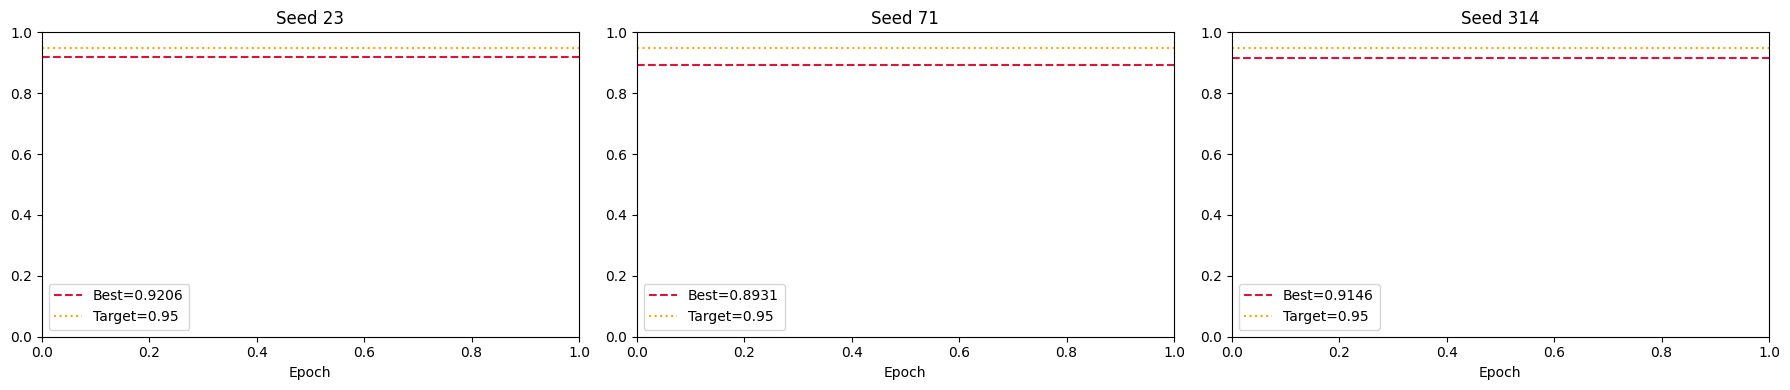

In [12]:
# ── 12. Training Curves (per seed) ────────────────────────────────────────────
# Load logs from checkpoints and plot
fig, axes = plt.subplots(1, len(SEEDS), figsize=(6*len(SEEDS), 4))
if len(SEEDS) == 1: axes = [axes]

for ax, seed, bf in zip(axes, SEEDS, best_f1s):
    ax.axhline(bf,   color="crimson", ls="--", label=f"Best={bf:.4f}")
    ax.axhline(0.95, color="orange",  ls=":",  label="Target=0.95")
    ax.set(title=f"Seed {seed}", xlabel="Epoch"); ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/curves.png", dpi=120); plt.show()


In [13]:
# ── 13. 3-Seed Ensemble Inference — 30-round TTA per model ───────────────────
def load_weights(bp):
    """Load weights from torch.compile checkpoint — strips _orig_mod. prefix."""
    raw = torch.load(bp, map_location=DEVICE)
    return {k.replace("_orig_mod.", ""): v for k, v in raw.items()}

print("Running 3-seed ensemble with 30-round TTA per model...")
sample_sub  = pd.read_csv(SAMPLE_SUB,
                          dtype={pd.read_csv(SAMPLE_SUB).columns[0]: str})
S_ID  = sample_sub.columns[0]
S_LBL = sample_sub.columns[1]
test_frm = sample_sub[[S_ID]].copy()

TTA_N         = 30
ensemble_bank = None

for seed, bp in zip(SEEDS, best_paths):
    print(f"\nSeed {seed} — loading {bp}...")

    m = WideResNet(depth=40, width=10, nc=NUM_CLASSES, drop=0.3).to(DEVICE)
    m.load_state_dict(load_weights(bp))   # ← fixed
    m.eval()

    model_bank = None

    # 30 TTA passes
    for rd in tqdm(range(TTA_N), desc=f"  TTA seed={seed}"):
        ds  = ImgDS(test_frm, TEST_IMGS, tta_tfm, S_ID, is_test=True)
        dl  = DataLoader(ds, batch_size=BATCH, shuffle=False,
                         num_workers=N_WORKERS, pin_memory=True)
        buf = []
        with torch.no_grad():
            for imgs, _ in dl:
                with autocast(enabled=AMP_OK):
                    out = m(imgs.to(DEVICE, non_blocking=True))
                buf.append(torch.softmax(out, 1).cpu().numpy())
        arr        = np.concatenate(buf)
        model_bank = arr if model_bank is None else model_bank + arr

    # 1 clean pass weighted 3x
    ds   = ImgDS(test_frm, TEST_IMGS, val_tfm, S_ID, is_test=True)
    dl   = DataLoader(ds, batch_size=BATCH, shuffle=False,
                      num_workers=N_WORKERS, pin_memory=True)
    cbuf = []
    with torch.no_grad():
        for imgs, _ in dl:
            with autocast(enabled=AMP_OK):
                out = m(imgs.to(DEVICE, non_blocking=True))
            cbuf.append(torch.softmax(out, 1).cpu().numpy())
    clean      = np.concatenate(cbuf)
    model_bank = (model_bank + 3*clean) / (TTA_N + 3)

    ensemble_bank = model_bank if ensemble_bank is None else ensemble_bank + model_bank
    print(f"  Seed {seed} done ✓")

    del m; torch.cuda.empty_cache()

# Average across all 3 models
ensemble_bank /= len(SEEDS)
preds = ensemble_bank.argmax(axis=1)
sub   = sample_sub.copy()
sub[S_LBL] = ([idx2cls[p] for p in preds]
              if sub[S_LBL].dtype == object else preds)
sub.to_csv(SUB_PATH, index=False)

print(f"\n✅ submission.csv saved → {SUB_PATH}  ({len(sub)} rows)")
print("Distribution:")
print(sub[S_LBL].value_counts().sort_index())
print(sub.head(10))

Running 3-seed ensemble with 30-round TTA per model...

Seed 23 — loading /kaggle/working/best_seed23.pth...


  TTA seed=23: 100%|██████████| 30/30 [04:07<00:00,  8.26s/it]


  Seed 23 done ✓

Seed 71 — loading /kaggle/working/best_seed71.pth...


  TTA seed=71: 100%|██████████| 30/30 [04:22<00:00,  8.74s/it]


  Seed 71 done ✓

Seed 314 — loading /kaggle/working/best_seed314.pth...


  TTA seed=314: 100%|██████████| 30/30 [04:05<00:00,  8.19s/it]


  Seed 314 done ✓

✅ submission.csv saved → /kaggle/working/submission.csv  (7600 rows)
Distribution:
label
airplane      541
automobile    549
bird          564
cat           670
deer          819
dog           818
frog          865
horse         912
ship          958
truck         904
Name: count, dtype: int64
       id       label
0  000001         cat
1  000002  automobile
2  000003         dog
3  000004        frog
4  000005         dog
5  000006        bird
6  000007        frog
7  000008        bird
8  000009        bird
9  000010        bird


In [14]:
# ── 14. Validation Report (Best Seed) ─────────────────────────────────────────
best_seed_idx = int(np.argmax(best_f1s))
best_seed     = SEEDS[best_seed_idx]
print(f"Showing report for best seed: {best_seed}  F1={best_f1s[best_seed_idx]:.4f}")

m = WideResNet(depth=40, width=10, nc=NUM_CLASSES, drop=0.3).to(DEVICE)
m.load_state_dict(torch.load(best_paths[best_seed_idx], map_location=DEVICE))
m.eval()

pv, lv = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(val_loader, desc="Val"):
        with autocast(enabled=AMP_OK):
            pv.extend(m(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        lv.extend(lbls.numpy())

print(classification_report(lv, pv, target_names=classes, digits=4))

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), int)
for t, p in zip(lv, pv): cm[t][p] += 1
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix | Seed={best_seed} F1={best_f1s[best_seed_idx]:.4f}")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion.png", dpi=120); plt.show()


Showing report for best seed: 23  F1=0.9206


RuntimeError: Error(s) in loading state_dict for WideResNet:
	Missing key(s) in state_dict: "stem.weight", "stage1.0.bn1.weight", "stage1.0.bn1.bias", "stage1.0.bn1.running_mean", "stage1.0.bn1.running_var", "stage1.0.conv1.weight", "stage1.0.bn2.weight", "stage1.0.bn2.bias", "stage1.0.bn2.running_mean", "stage1.0.bn2.running_var", "stage1.0.conv2.weight", "stage1.0.proj.weight", "stage1.1.bn1.weight", "stage1.1.bn1.bias", "stage1.1.bn1.running_mean", "stage1.1.bn1.running_var", "stage1.1.conv1.weight", "stage1.1.bn2.weight", "stage1.1.bn2.bias", "stage1.1.bn2.running_mean", "stage1.1.bn2.running_var", "stage1.1.conv2.weight", "stage1.2.bn1.weight", "stage1.2.bn1.bias", "stage1.2.bn1.running_mean", "stage1.2.bn1.running_var", "stage1.2.conv1.weight", "stage1.2.bn2.weight", "stage1.2.bn2.bias", "stage1.2.bn2.running_mean", "stage1.2.bn2.running_var", "stage1.2.conv2.weight", "stage1.3.bn1.weight", "stage1.3.bn1.bias", "stage1.3.bn1.running_mean", "stage1.3.bn1.running_var", "stage1.3.co